In [1]:
from src.utils import get_path, find_closest_power_of_2, set_device
from src.QDDPM_torch_angel import WassDistance
from opt_einsum import contract
from qutip import Bloch
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import torch

def bloch_xyz(inputs):
    # obtain bloch sphere representation vector
    rho = contract('mi,mj->mij', inputs, inputs.conj())
    sigmas = [qt.sigmax().full(), qt.sigmay().full(), qt.sigmaz().full()]
    pos = [np.real(contract('mii->m', contract('mij,jk->mik', rho, x))) for x in sigmas]
    return pos

Please first ``pip install -U qiskit`` to enable related functionality in translation module
Please first ``pip install -U cirq`` to enable related functionality in translation module
fail to load cloud provider module: tencent


In [18]:
# Fake config file to use get_path()
# EDITABLE
config = {
    'device': 'cpu',
    'seed': 0,
    'dataset': {
        'dir': './data',
        'name': 'MNIST_1',
        'transforms': {
            'resize': 16
        },
        'maxsize': 500,
    },
    'model': {
        'n_timesteps': 40,
        'diffusion_schedule': {
            'name': 'linear',
            'slope': 2,
            # 'vrescale': 50,
            # 'hrescale': 26
        }
    }
}
# n_qubits = int(config["dataset"]["name"].split('_')[1])
n_features = int(config["dataset"]["transforms"]["resize"])**2
diffusion_schedule_nickname = config['model']['diffusion_schedule']['name']

n_data = config['dataset']['maxsize']
n_timesteps = config['model']['n_timesteps']
diffusion_schedule = config["model"]["diffusion_schedule"]["name"] + str(config["model"]["diffusion_schedule"]["slope"])# + "-" + str(config["model"]["diffusion_schedule"]["vrescale"]) + "-" + str(config["model"]["diffusion_schedule"]["hrescale"])
_, n_qubits = find_closest_power_of_2(n_features, return_power=True)

device = set_device(config.get('device', 'cpu'))
torch.set_default_device(device)

Using device: cpu


(0.0, 1.9999998807907104)

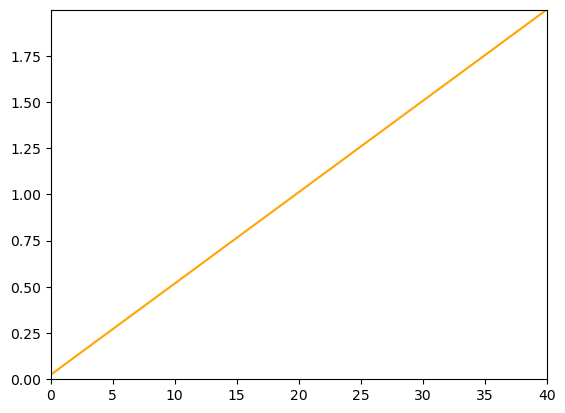

In [19]:
# Get diff weights also
# slope = config["model"]["diffusion_schedule"]["slope"]
# vrescale = config["model"]["diffusion_schedule"]["vrescale"]
# hrescale = config["model"]["diffusion_schedule"]["hrescale"]
# x = torch.linspace(1., n_timesteps+1, steps=n_timesteps+1, device=device)
# diffusion_weights = slope*torch.log(x / (vrescale - x)) + hrescale

slope = config["model"]["diffusion_schedule"]["slope"]
# diffusion_weights = 1/(n_timesteps+1) * torch.linspace(1., slope*torch.tensor(n_timesteps+1), n_timesteps+1, device=device)

x = torch.linspace(0., n_timesteps+1, steps=n_timesteps+1, device=device)
# diffusion_weights = slope*torch.pow(x, 2)
diffusion_weights = 1/(n_timesteps+1) * torch.linspace(1., slope*torch.tensor(n_timesteps+1), n_timesteps+1, device=device)

plt.plot(diffusion_weights.cpu().numpy(), c='orange')
plt.xlim(0, n_timesteps)
plt.ylim(0, max(diffusion_weights.detach().cpu().numpy()))

# Diffuse

In [ ]:
# from diffuse import main as diffuse
# diffuse(config, n_data, n_features, n_timesteps, diffusion_schedule, overwrite=True)
from src.trainers.basic_trainers import QDDPMGeneratorInitialqstates
from src.QDDPM_torch_angel import QDDPMDiffuser
from src.utils import get_diffusion_weights

type = config["model"]["diffusion_schedule"]["name"]
if type == 'linear':
    slope = config['model']['diffusion_schedule']['slope']
    diffusion_schedule_nickname = type + str(slope)
dir, filename = get_path(config, type='diffusedqstates.npy', diffusion_schedule_nickname=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
path = dir/filename
# Check if initial states exist
dir, filename = get_path(config, type='initialqstates.npy', n_data=n_data, n_features=n_features, n_qubits=n_qubits)
path = dir/filename
if not path.exists() or True:
    # Generate initial states
    print("Initial quantum states not found. Generating them...")
    generator_initialqstates = QDDPMGeneratorInitialqstates(config)
    generator_initialqstates.generate_initialqstates()

# Everything checked. Diffuse.
diffuser = QDDPMDiffuser(n_qubits, n_timesteps, n_data, device=device)
diffusion_weights = get_diffusion_weights(config, device=device)
states_diffused = torch.zeros((n_timesteps+1, n_data, n_features), dtype=torch.complex64, device=device)
dir, filename = get_path(config, type='initialqstates.npy', n_data=n_data, n_features=n_features, n_qubits=n_qubits)
initialqstates = torch.from_numpy(np.load(dir/filename))
states_diffused[0] = initialqstates
for t in tqdm(range(1, n_timesteps+1)):
            # states[t] = model.set_diffusionData_t(t, states[0], diffusion_weights[:t], seed=t)
            states_diffused[t] = diffuser.set_diffusionData_t_single_step(t, states_diffused[t-1], diffusion_weights[:t], seed=t)
            states_diffused[t] = states_diffused[t] / torch.norm(states_diffused[t], dim=1, keepdim=True) # Avoid numerical errorsdir, filename = get_path(config, type='diffusedqstates.npy', diffusion_schedule=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
dir, filename = get_path(config, type='diffusedqstates.npy', diffusion_schedule_nickname=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
np.save(dir/filename, states_diffused.cpu().numpy())

Initial quantum states not found. Generating them...
Digit: 1
Batch size: 500
Loaded dataset MNIST_1 with 500 samples.
Dataset saved in data/MNIST_1/initialqstates/initialqstates_MNIST_1_N500_M256_n8.npy


100%|██████████| 40/40 [00:22<00:00,  1.75it/s]


In [21]:
# Wasserstein distance
dir, filename = get_path(config, type='diffusedqstates.npy', diffusion_schedule_nickname=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
diffused_states = torch.from_numpy(np.load(dir / filename))

wass = np.zeros(n_timesteps+1)
for t in tqdm(range(n_timesteps+1)):
    np.random.seed()
    wass[t] = WassDistance(diffused_states[0], diffused_states[t]).detach().numpy()

dir, filename = get_path(config, type='wassdistforward.npy', diffusion_schedule_nickname=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
np.save(dir / filename, wass)

  0%|          | 0/41 [00:00<?, ?it/s]

100%|██████████| 41/41 [00:00<00:00, 43.85it/s] 


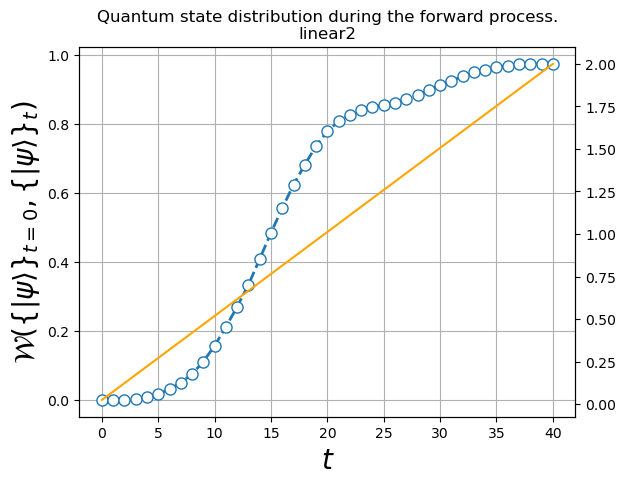

In [22]:
dir, filename = get_path(config, type='wassdistforward.npy', diffusion_schedule_nickname=diffusion_schedule_nickname, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
wass = np.load(dir / filename)

from src.utils import get_diffusion_weights
diffusion_weights = get_diffusion_weights(config, device)

fig, ax1 = plt.subplots()
ax1.plot(wass, 'o--', mfc='white', markersize=8, lw=2)
# plt.plot(wass)
ax1.set_ylabel(r'$\mathcal{W}\left(\{|\psi\rangle\}_{t=0}, \{|\psi\rangle\}_{t} \right)$', fontsize=20)
ax1.set_xlabel(r'$t$', fontsize=20)
# plt.xticks(range(n_timesteps+1))
ax1.grid(True)
ax1.set_title(f'Quantum state distribution during the forward process.\n{diffusion_schedule_nickname}')

ax2 = ax1.twinx()
ax2.plot(diffusion_weights.cpu(), c='orange', label='Diffusion weight')

In [ ]:
# Compare schedules
n_timesteps = 20
dir, filename = get_path(config, type='wassdistforward', diffusion_schedule='linear', n_data=n_data, n_pixels=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
wass1 = np.load(dir / filename)
dir, filename = get_path(config, type='wassdistforward', diffusion_schedule='pow6', n_data=n_data, n_pixels=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
wass2 = np.load(dir / filename)
dir, filename = get_path(config, type='wassdistforward', diffusion_schedule='pow100', n_data=n_data, n_pixels=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
wass3 = np.load(dir / filename)
dir, filename = get_path(config, type='wassdistforward', diffusion_schedule='powint4', n_data=n_data, n_pixels=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
wass4 = np.load(dir / filename)
dir, filename = get_path(config, type='wassdistforward', diffusion_schedule='lin2T', n_data=n_data, n_pixels=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
wass5 = np.load(dir / filename)
dir, filename = get_path(config, type='wassdistforward', diffusion_schedule='lin3T', n_data=n_data, n_pixels=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
wass6 = np.load(dir / filename)
dir, filename = get_path(config, type='wassdistforward', diffusion_schedule='lin2T', n_data=n_data, n_pixels=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps+2)
wass7 = np.load(dir / filename)
dir, filename = get_path(config, type='wassdistforward', diffusion_schedule='lin2.5T', n_data=n_data, n_pixels=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
wass8 = np.load(dir / filename)
dir, filename = get_path(config, type='wassdistforward', diffusion_schedule='linear1', n_data=n_data, n_pixels=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
wass8 = np.load(dir / filename)

plt.plot(wass1, 'o--', label='Abans', mfc='white', markersize=8, lw=2)
# plt.plot(wass2, 'o--', label='pow6', mfc='white', markersize=8, lw=2)
# plt.plot(wass3, 'o--', label='pow100', mfc='white', markersize=8, lw=2)
# plt.plot(wass4, 'o--', label='powint4', mfc='white', markersize=8, lw=2)
# plt.plot(wass5, 'o--', label='lin2T', mfc='white', markersize=8, lw=2)
# plt.plot(wass6, 'o--', label='lin3T', mfc='white', markersize=8, lw=2)
# plt.plot(wass7, 'o--', label='lin2T+2', mfc='white', markersize=8, lw=2)
plt.plot(wass8, 'o--', label='Ara', mfc='white', markersize=8, lw=2)
plt.ylabel(r'$W(t)$', fontsize=20)
plt.xlabel(r'$t$', fontsize=20)
plt.xticks(range(n_timesteps+3))
plt.grid(True)
plt.legend()
plt.title(f'Evolution of the quantum state distribution through the scrambling circuits')

FileNotFoundError: [Errno 2] No such file or directory: 'data/MNIST0/diffusedqstates/wassdistforward_MNIST0_schedulelinear1_N1000_M64_n6_T40.npy'

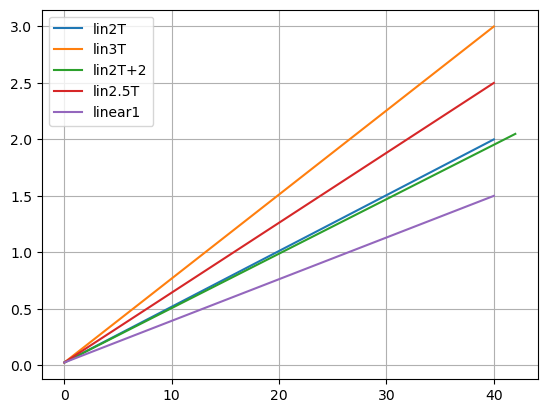

In [8]:
import torch
# linear_steps = torch.linspace(1., torch.sqrt(torch.tensor(4)), n_timesteps, device='cpu')
# diffusion_weights = torch.pow(linear_steps, 2)
# plt.plot(diffusion_weights, label='quadratic')

# linear_steps = torch.linspace(1., 4, n_timesteps, device='cpu')
# plt.plot(linear_steps, label='linear')

# linear_steps = torch.linspace(1., torch.pow(torch.tensor(4), 1/3), n_timesteps, device='cpu')
# diffusion_weights = torch.pow(linear_steps, 3)
# plt.plot(diffusion_weights, label='cubic')

# n=100
# linear_steps = torch.linspace(1., torch.pow(torch.tensor(4), 1/n), n_timesteps, device='cpu')
# diffusion_weights = torch.pow(linear_steps, n)
# plt.plot(diffusion_weights, label=f'n={n}')

# n=4
# linear_steps = torch.linspace(1., torch.tensor(n_timesteps+1), n_timesteps+1, device='cpu')
# diffusion_weights = 2*torch.pow((linear_steps/(n_timesteps+1)), n)
# plt.plot(diffusion_weights, label=f'custom n={n}')

# diffusion_weights = 1e-3*np.arange(1, n_timesteps+1)**2
# plt.plot(diffusion_weights, label=f'circular')

# x = 1/(n_timesteps+1)*torch.linspace(1., torch.tensor(2*n_timesteps+1), n_timesteps+1, device='cpu')
# plt.plot(x, label='linT')

x = 1/(n_timesteps+1)*torch.linspace(1., 2*torch.tensor(n_timesteps+1), n_timesteps+1, device=device)
plt.plot(x, label='lin2T')

x = 1/(n_timesteps+1)*torch.linspace(1., 3*torch.tensor(n_timesteps+1), n_timesteps+1, device=device)
plt.plot(x, label='lin3T')

x = 1/(n_timesteps+1)*torch.linspace(1., 2*torch.tensor(n_timesteps+2), n_timesteps+3, device=device)
plt.plot(x, label='lin2T+2')

x = 1/(n_timesteps+1)*torch.linspace(1., 2.5*torch.tensor(n_timesteps+1), n_timesteps+1, device=device)
plt.plot(x, label='lin2.5T')

x = 1/(n_timesteps+1)*torch.linspace(1., 1.5*torch.tensor(n_timesteps+1), n_timesteps+1, device=device)
plt.plot(x, label='linear1')

# plt.xticks(range(n_timesteps+3))
plt.grid(True)
plt.legend()

100%|██████████| 51/51 [00:00<00:00, 3179.53it/s]


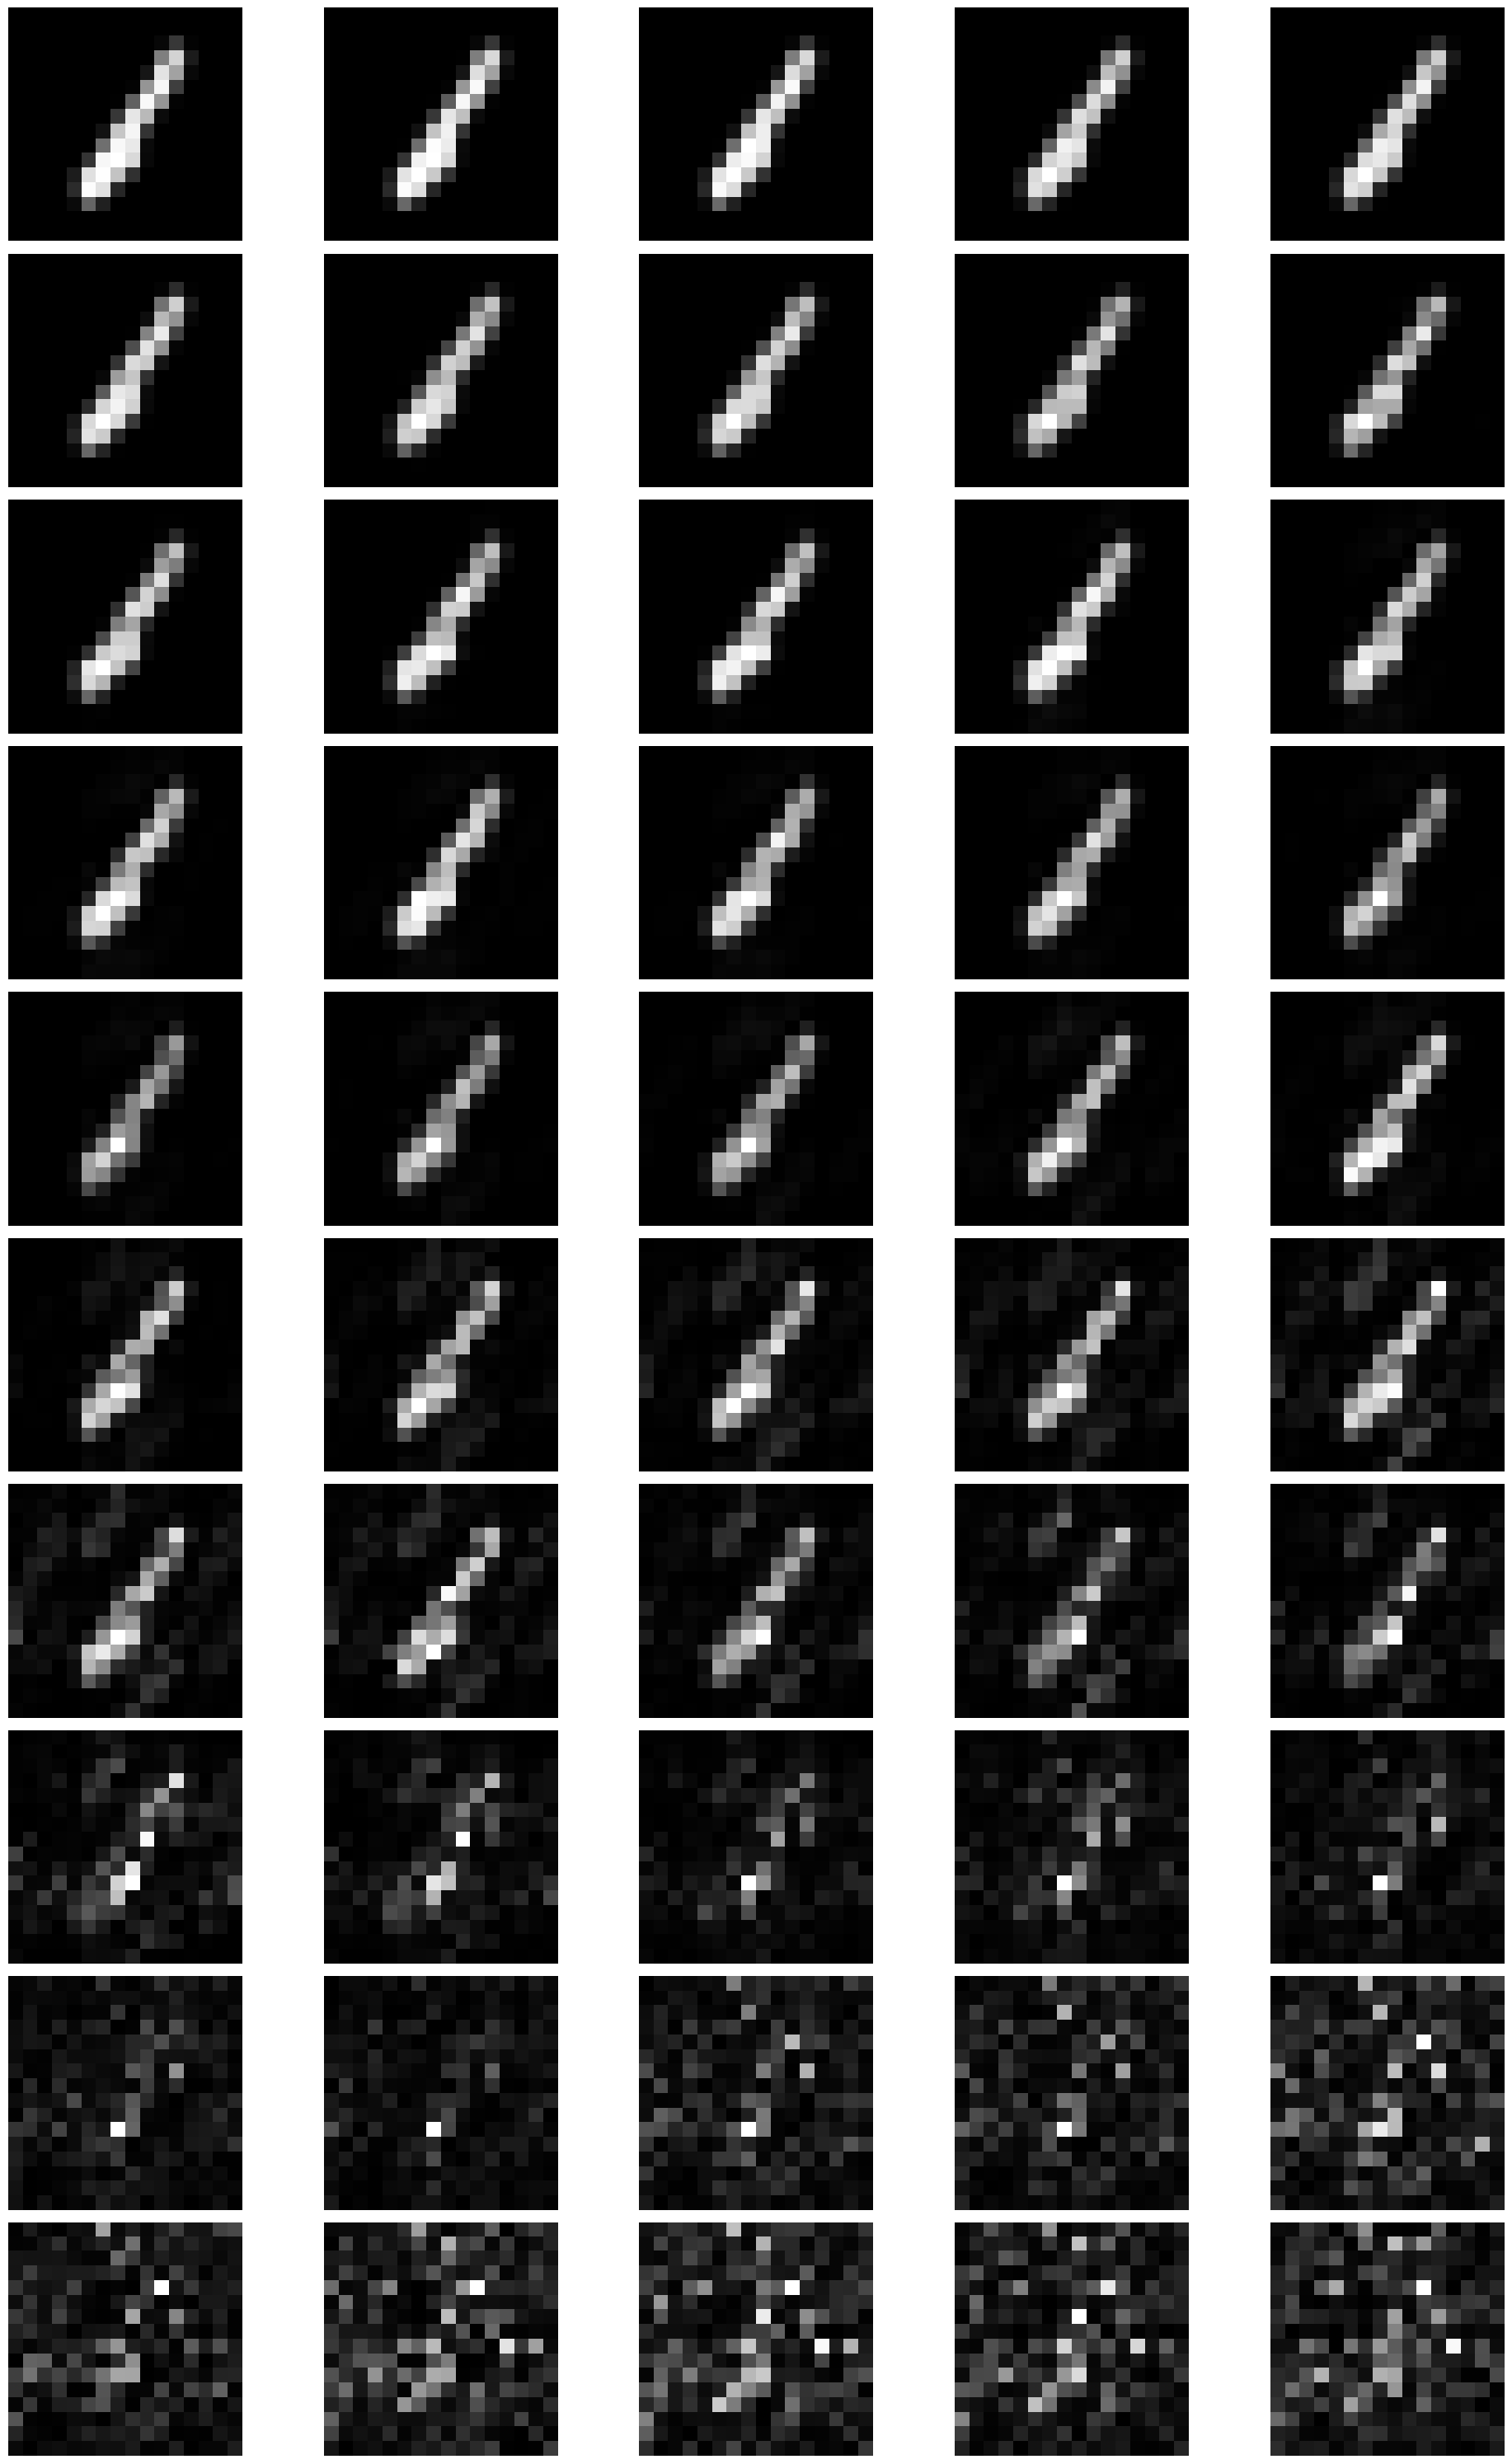

In [41]:
# Visualize the evolution of one image
n = 2 # select a sample

dir, filename = get_path(config, type='diffusedqstates.npy', diffusion_schedule=diffusion_schedule, n_data=n_data, n_features=n_features, n_qubits=n_qubits,n_timesteps=n_timesteps)
diffused_states = np.load(dir / filename)

image_dim = int(np.sqrt(n_features))
rows = 10
cols = 5
fig, axs = plt.subplots(rows, cols, figsize=(20, 30))
vmin, vmax = 0, 1
images = []
for i in tqdm(range(n_timesteps+1)):
    if i == n_timesteps:
        continue
    # Extract the probabilities and convert back to MNIST digits
    state = diffused_states[i+1, n]
    probs = (state*state.conj()).real
    probs = probs[:, np.newaxis][:n_features]
    image = probs.reshape(image_dim, image_dim)

    # Rescale the probabilities to the range [0,1]
    norm = 1 / image.max()
    image = image * norm

    images.append(image)

    axs[i//cols, i%cols].imshow(image, vmin=vmin, vmax=vmax, cmap='gray')
    axs[i//cols, i%cols].axis('off')

plt.tight_layout()

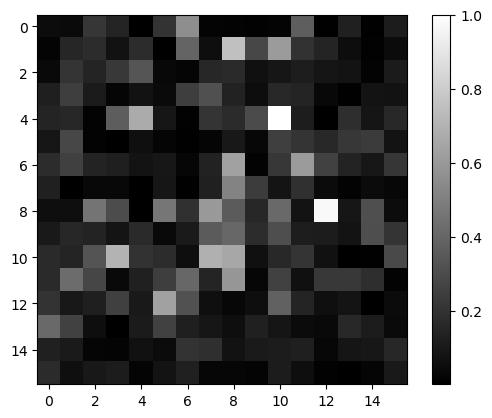

In [42]:
plt.imshow(image, cmap='gray')
plt.colorbar()

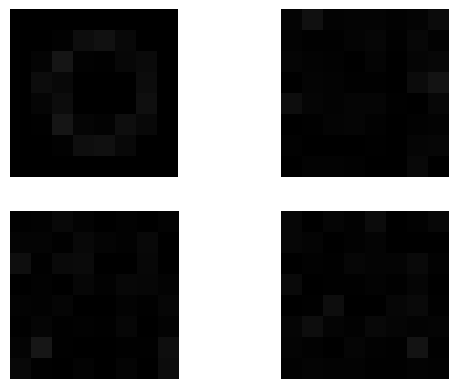

In [ ]:
fig, ax = plt.subplots(2,2)
vmin, vmax = 0, 1
for i in range(4):
    ax[i//2, i%2].imshow(images[-i], vmin=vmin, vmax=vmax, cmap='gray')
    ax[i//2, i%2].axis('off')


In [1]:
# Bloch visualize on the forward noise process
dir, filename = get_path(config, type='diffusedqstates', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_features, n_qubits=n_qubits,n_timesteps=n_timesteps)
diffused_states = np.load(dir / filename)

rows = 5
cols = 8
fig, axs = plt.subplots(rows, cols, figsize=(14,10), subplot_kw={'projection': '3d'})
for i in tqdm(range(n_timesteps+1)):
    xs0, ys0, zs0 = bloch_xyz(diffused_states[i])
    b0 = Bloch(fig=fig, axes=axs[i//cols, i%cols])
    b0.clear()
    b0.add_points([xs0, ys0, zs0])
    b0.point_color = ['r']*n_data
    b0.point_style = 'm'
    b0.point_size = 8*np.ones(n_data)
    b0.render()
plt.tight_layout()

NameError: name 'get_path' is not defined